In [90]:
import numpy as np
import matplotlib.pyplot as plt
import kymatio
import math
import ot
import matplotlib.ticker as ticker
from ST import *
from PS import compute_flux_power_spectrum
from statistical_distance import *
from scaling_flux import *

In [91]:
redshift = 2

In [92]:
hybrid_tau = np.load(f'hybrid/hybrid_tau_z{redshift}.npy')
hybrid_flux = np.exp(-hybrid_tau)

nspectra = hybrid_tau.shape[0]
print('number of spectra:', hybrid_flux.shape[0], 'length of spectra:',  hybrid_flux.shape[1])

number of spectra: 5000 length of spectra: 3390


In [93]:
thermal_tau = np.load(f'thermal/thermal_tau_z{redshift}.npy')
thermal_flux = np.exp(-thermal_tau)

nspectra = thermal_tau.shape[0]
print('number of spectra:', thermal_flux.shape[0], 'length of spectra:',  thermal_flux.shape[1])

number of spectra: 5000 length of spectra: 3283


In [94]:
mean_flux = compute_desired_mean_flux(redshift)
alpha_hybrid = compute_flux_scale_factor(hybrid_tau, mean_flux)
scaled_hybrid_flux = np.exp(-hybrid_tau * alpha_hybrid)

alpha_thermal= compute_flux_scale_factor(thermal_tau, mean_flux)
scaled_thermal_flux = np.exp(-thermal_tau * alpha_thermal)

In [95]:
J = math.floor(np.log(scaled_thermal_flux.shape[1]))
print(J)

8


In [96]:
coefficients_hybrid, meta_hybrid = flux_scattering_transform(scaled_hybrid_flux, J)
coefficients_hybrid = coefficients_hybrid.mean(axis=2)
print(coefficients_hybrid.shape)

(5000, 43)


In [97]:
coefficients_thermal, meta_thermal = flux_scattering_transform(scaled_thermal_flux, J)
coefficients_thermal = coefficients_thermal.mean(axis=2)
print(coefficients_thermal.shape)

(5000, 43)


In [98]:
#normalization, calculating mean and standard deviation
S1_hybrid, S2_hybrid = get_normalized_coefficients(coefficients_hybrid, meta_hybrid)
S1_hybrid_mean = np.mean(S1_hybrid['S1'], axis=0)
S1_hybrid_std = np.std(S1_hybrid['S1'], axis=0)
S2_hybrid_mean = [np.mean(S2_hybrid['S2'][f'{j}'], axis=0) for j in range(len(S2_hybrid['S2']))]
S2_hybrid_std = [np.std(S2_hybrid['S2'][f'{j}'], axis=0) for j in range(len(S2_hybrid['S2']))]

In [99]:
#normalization, calculating mean and standard deviation
S1_thermal, S2_thermal = get_normalized_coefficients(coefficients_thermal, meta_thermal)
S1_thermal_mean = np.mean(S1_thermal['S1'], axis=0)
S1_thermal_std = np.std(S1_thermal['S1'], axis=0)
S2_thermal_mean = [np.mean(S2_thermal['S2'][f'{j}'], axis=0) for j in range(len(S2_thermal['S2']))]
S2_thermal_std = [np.std(S2_thermal['S2'][f'{j}'], axis=0) for j in range(len(S2_thermal['S2']))]

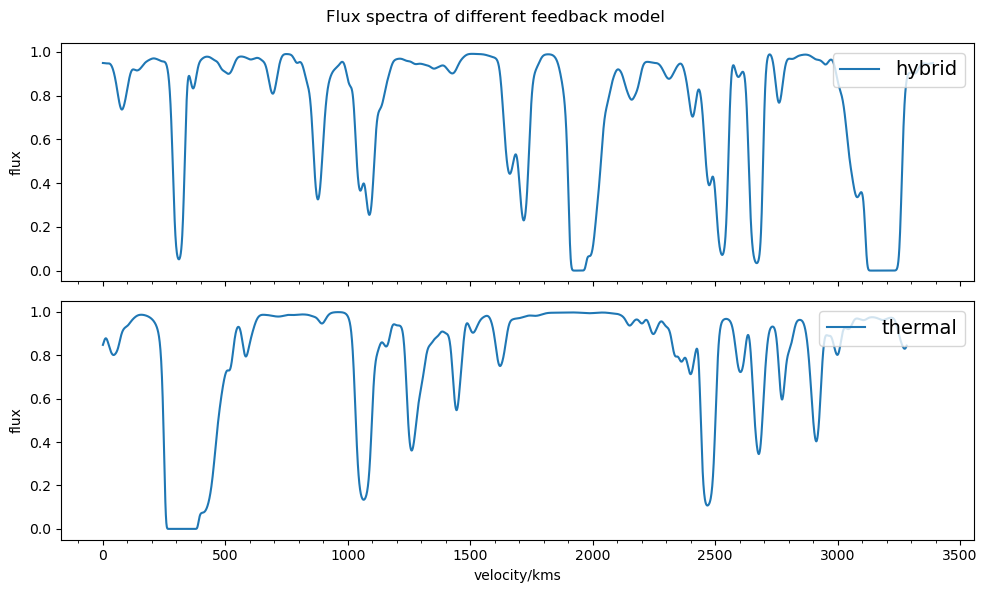

In [100]:
#plot redshift 4 spectra
n = 100
fig, axs = plt.subplots(2, 1, figsize=(10, 6),
                        sharex=True)

axs[0].plot(scaled_hybrid_flux[n], label='hybrid')
axs[1].plot(scaled_thermal_flux[n], label='thermal')

for ax in axs:
    ax.set_ylabel('flux')
    ax.legend(loc='upper right', fontsize=14)
    
axs[1].set_xlabel('velocity/kms')
axs[1].xaxis.set_minor_locator(ticker.MultipleLocator(100))
fig.suptitle('Flux spectra of different feedback model')
fig.tight_layout()

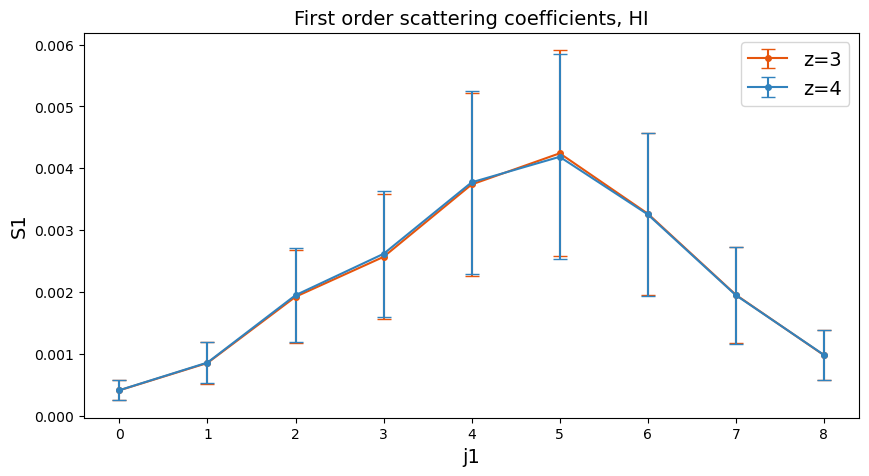

In [101]:
#plot the first order coefficients
fig, axs = plt.subplots(1, figsize=(10, 5))
j1 = np.array(list(S1_thermal['j1'].flatten()))[:, 0]

colors = ['#3182BD', '#31A354', '#E6550D'] 
axs.errorbar(j1, S1_hybrid_mean, S1_hybrid_std, fmt='-o', label='z=3', markersize=4, capsize=5, color=colors[2])
axs.errorbar(j1, S1_thermal_mean, S1_thermal_std, fmt='-o', label='z=4', markersize=4, capsize=5, color=colors[0])
axs.set_title('First order scattering coefficients, HI', fontsize=14)
axs.set_xticks(j1)
axs.set_xlabel('j1', fontsize=14)
axs.set_ylabel('S1', fontsize=14)
axs.legend(fontsize=14)

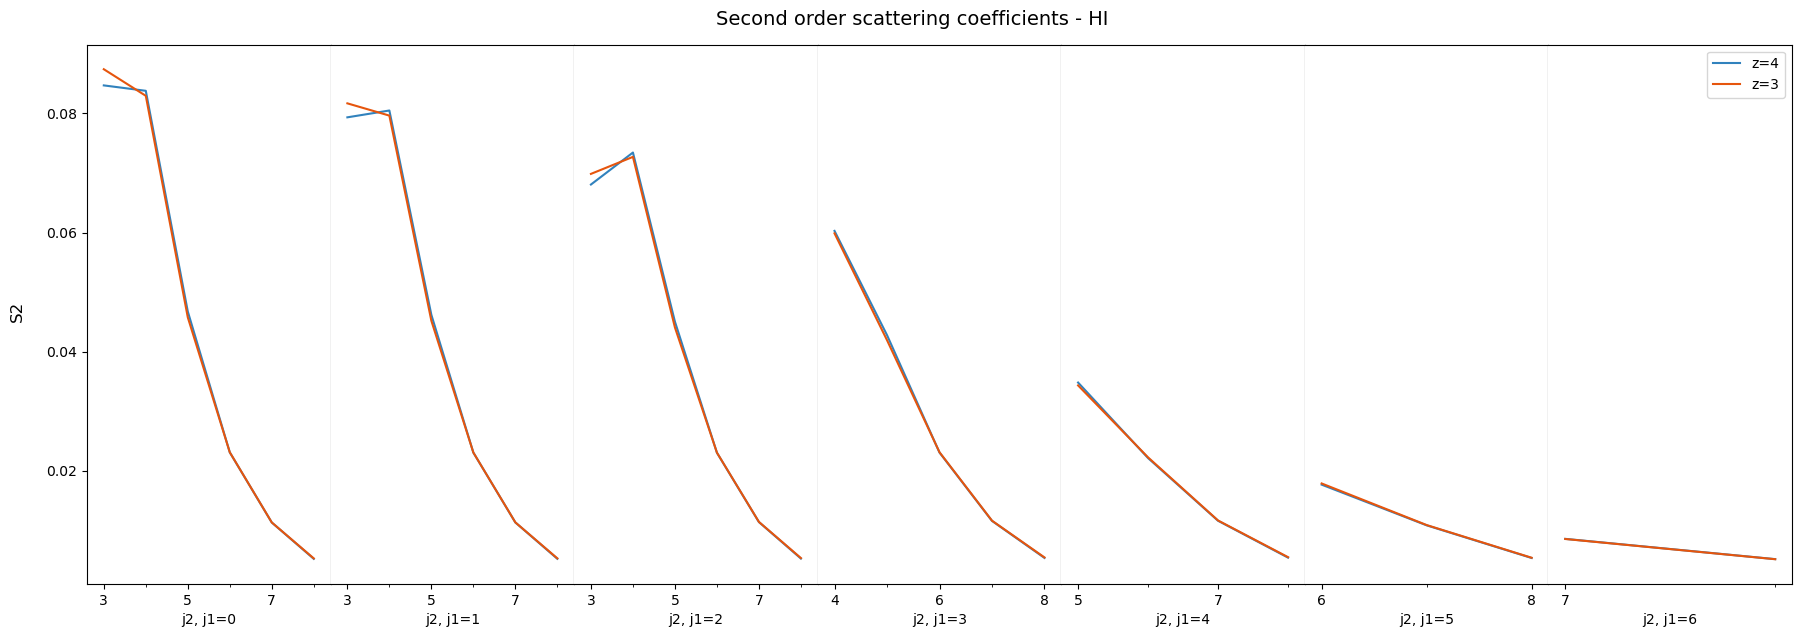

In [102]:
#plot the second order scattering 
fig, axes = plt.subplots(1, len(S2_thermal_mean[:-1]), figsize=(22, 7), sharey=True)
fig.subplots_adjust(wspace=0.0) 
fig.suptitle('Second order scattering coefficients - HI', y=0.93, fontsize=14)
fig.supylabel('S2', x=0.09)

for j, (ax, s2_hybrid, s2_thermal) in enumerate(zip(axes, S2_hybrid_mean, S2_thermal_mean)):
    j2_labels = [e[1] for e in S2_hybrid['j1_j2'][j]]
    ax.plot(s2_hybrid, label='z=4', color=colors[0])
    ax.plot(s2_thermal, label='z=3', color=colors[2])
    ax.set_xlabel(f'j2, j1={j}')
    ax.set_xticks(range(0, len(s2_hybrid), 2))
    ax.set_xticklabels(j2_labels[::2])
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.margins(x=0.08)

    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.9, 0.88))


In [103]:
ps_hybrid = compute_flux_power_spectrum(scaled_hybrid_flux[:, :thermal_flux.shape[1]], 1)
ps_thermal = compute_flux_power_spectrum(scaled_thermal_flux, 1)

ps_hybrid_mean = ps_hybrid.mean(axis=0)
ps_thermal_mean = ps_thermal.mean(axis=0)

In [104]:
N_thermal = scaled_thermal_flux.shape[1]
k_thermal = np.fft.fftfreq(N_thermal, d=1)
k_range = N_thermal//2

Text(0.5, 0.92, 'Flux power spectrum  of different feedback model')

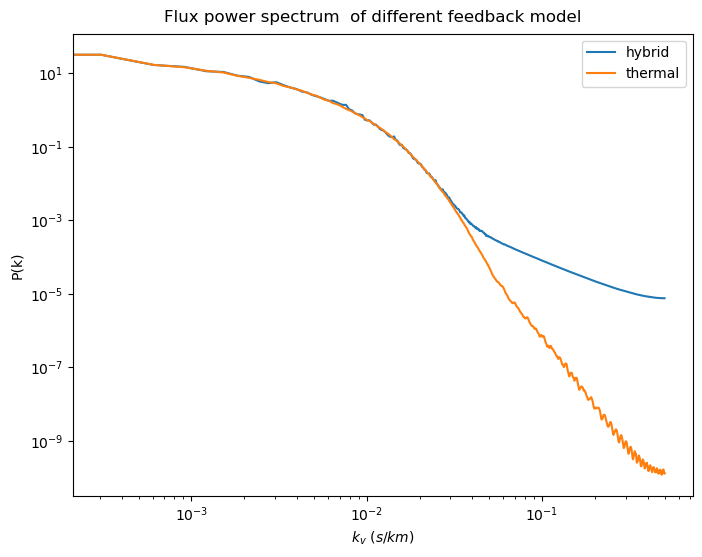

In [105]:
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.loglog(k_thermal[:k_range], ps_hybrid_mean[:k_range], label='hybrid')
ax.loglog(k_thermal[:k_range], ps_thermal_mean[:k_range], label='thermal')
ax.set_xlabel('$k_{v}$ $(s/km)$')
ax.set_ylabel('P(k)')
ax.legend()
fig.suptitle('Flux power spectrum  of different feedback model',x=0.5, y=0.92)

In [106]:
#normalize statistics
ps_hybrid_normalized = statistics_normalizaiton(ps_hybrid)
ps_thermal_normalized = statistics_normalizaiton(ps_thermal)

ps_hybrid_normalized_mean = ps_hybrid_normalized.mean(axis=0)
ps_thermal_normalized_mean = ps_thermal_normalized.mean(axis=0)

In [107]:
S1_hybrid_normalized = statistics_normalizaiton(S1_hybrid['S1'])
S1_thermal_normalized = statistics_normalizaiton(S1_thermal['S1'])

S1_hybrid_normalized_mean = S1_hybrid_normalized.mean(axis=0)
S1_thermal_normalized_mean = S1_thermal_normalized.mean(axis=0)

In [108]:
PS_distance = compute_mahalanobis_distance(ps_hybrid_normalized[:, :k_range], ps_hybrid_normalized_mean[:k_range], ps_thermal_normalized[:, :k_range], ps_thermal_normalized_mean[:k_range])
S1_distance = compute_mahalanobis_distance(S1_hybrid_normalized, S1_hybrid_normalized_mean, S1_thermal_normalized, S1_thermal_normalized_mean)

In [109]:
PS_distance_normalized = PS_distance / np.sqrt(k_range)
S1_distance_normalized = S1_distance / np.sqrt(J+1)
print(S1_distance_normalized, PS_distance_normalized)

0.5591678526777439 0.04605985913997401
